In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
from natsort import natsorted
import duckdb
from tqdm import tqdm 
import numpy as np

In [2]:
TURKEY_ELECTION_DATE_FIRST_ROUOND = "2023-05-14"
TURKEY_ELECTION_DATE_SECOND_ROUOND = "2023-05-28"
US_ELECTION_DATE = "2024-11-05"
FINLAND_ELECTION_DATE = "2023-04-02"

In [ ]:
turkey_twitter_sents_path_1   =  "/chistera/CaseStudyOutputs/turkish_election2023_enrichments/sentiment/*.jsonl"
turkey_twitter_sents_path_2  =  "/chistera/CaseStudyOutputs/turkish_election2023_enrichmetns/sentiment_v1/*.jsonl"

usc_twitter_sents_path      =  "/chistera/CaseStudyOutputs/usc_twitter_enrichments/sentiment/*.jsonl"
usc_truthsocial_sents_path  =  "/chistera/CaseStudyOutputs/usc_truthsocial_enrichments/sentiment/*.jsonl"
finnish_twitter_sents_path  =  "/chistera/CaseStudyOutputs/finnish_db_enrichments/sentiment/*.jsonl"

In [ ]:
con = duckdb.connect()
con.execute("SET TimeZone = 'UTC';")

start_date = '2023-01-01'
end_date = '2023-07-01'

turkey_twitter_df = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_neu,
            CAST(body->'scores'->>'LABEL_2' AS FLOAT) as p_pos
        FROM read_json_auto([
            '{turkey_twitter_sents_path_1}', 
            '{turkey_twitter_sents_path_2}'
        ])
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            date_trunc('day', ts) as day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    ),
    daily_stats AS (
        SELECT 
            day, 
            AVG(record_sentiment) as daily_sentiment,
            COUNT(*) as volume
        FROM scored_data
        GROUP BY 1
    )
    SELECT 
        day,
        daily_sentiment,
        AVG(daily_sentiment) OVER () as range_mean_sentiment,
        (daily_sentiment - AVG(daily_sentiment) OVER ()) as sentiment_deviation,
        volume
    FROM daily_stats
    ORDER BY day
""").df()

In [33]:
con = duckdb.connect()

con.execute("SET TimeZone = 'UTC';")

start_date = '2024-06-01'
end_date = '2024-12-01'

us_twitter_df = con.sql(f"""
   WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_neu,
            CAST(body->'scores'->>'LABEL_2' AS FLOAT) as p_pos
        FROM read_json_auto('{usc_twitter_sents_path}')
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            date_trunc('day', ts) as day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    ),
    daily_stats AS (
        SELECT 
            day, 
            AVG(record_sentiment) as daily_sentiment,
            COUNT(*) as volume
        FROM scored_data
        GROUP BY 1
    )
    SELECT 
        day,
        daily_sentiment,
        AVG(daily_sentiment) OVER () as range_mean_sentiment,
        (daily_sentiment - AVG(daily_sentiment) OVER ()) as sentiment_deviation,
        volume
    FROM daily_stats
    ORDER BY day
""").df()

In [4]:
con = duckdb.connect()

con.execute("SET TimeZone = 'UTC';")

start_date = '2024-06-01'
end_date = '2024-12-01'

us_truthsocial_df = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_neu,
            CAST(body->'scores'->>'LABEL_2' AS FLOAT) as p_pos
        FROM read_json_auto('{usc_truthsocial_sents_path}')
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            date_trunc('day', ts) as day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    ),
    daily_stats AS (
        SELECT 
            day, 
            AVG(record_sentiment) as daily_sentiment,
            COUNT(*) as volume
        FROM scored_data
        GROUP BY 1
    )
    SELECT 
        day,
        daily_sentiment,
        AVG(daily_sentiment) OVER () as range_mean_sentiment,
        (daily_sentiment - AVG(daily_sentiment) OVER ()) as sentiment_deviation,
        volume
    FROM daily_stats
    ORDER BY day
""").df()

In [23]:
con = duckdb.connect()

con.execute("SET TimeZone = 'UTC';")

start_date = '2022-10-01'
end_date = "2023-04-02"

finnish_twitter_df = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_pos
        FROM read_json_auto('{finnish_twitter_sents_path}')
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            date_trunc('day', ts) as day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    ),
    daily_stats AS (
        SELECT 
            day, 
            AVG(record_sentiment) as daily_sentiment,
            COUNT(*) as volume
        FROM scored_data
        GROUP BY 1
    )
    SELECT 
        day,
        daily_sentiment,
        AVG(daily_sentiment) OVER () as range_mean_sentiment,
        (daily_sentiment - AVG(daily_sentiment) OVER ()) as sentiment_deviation,
        volume
    FROM daily_stats
    ORDER BY day
""").df()

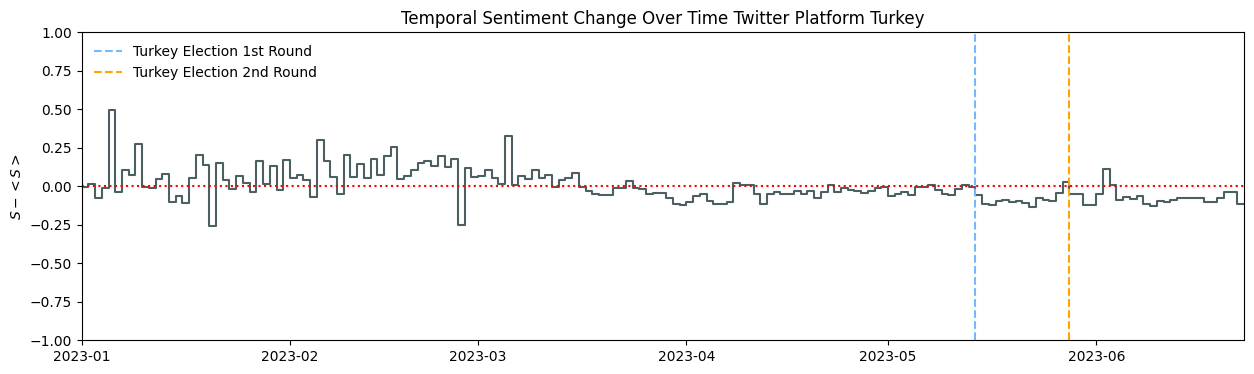

In [ ]:
plt.figure(figsize=(15, 4))
plt.step(turkey_twitter_df['day'], turkey_twitter_df['sentiment_deviatixon'], where='pre',  color="#4c5f63")
plt.axvline(pd.to_datetime(TURKEY_ELECTION_DATE_FIRST_ROUOND), color='#74b9ff', linestyle='--', label='Turkey Election 1st Round')
plt.axvline(pd.to_datetime(TURKEY_ELECTION_DATE_SECOND_ROUOND), color='orange', linestyle='--', label='Turkey Election 2nd Round')

plt.hlines(0, xmin=pd.to_datetime('2022-07-01'), xmax=pd.to_datetime('2023-06-23'), colors='red', linestyles='dotted')
plt.title('Temporal Sentiment Index Over Time')
plt.ylabel('$S - <S>$')
plt.legend(frameon=False)
plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-06-23'))
plt.title('Temporal Sentiment Change Over Time Twitter Platform Turkey')

# set xlabels monthly 2023-01 to 2023-06
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

plt.ylim(-1.0, 1.0)
plt.savefig('temporal_sentiment_change_twitter_turkey.pdf', dpi=300, bbox_inches='tight')
plt.show()

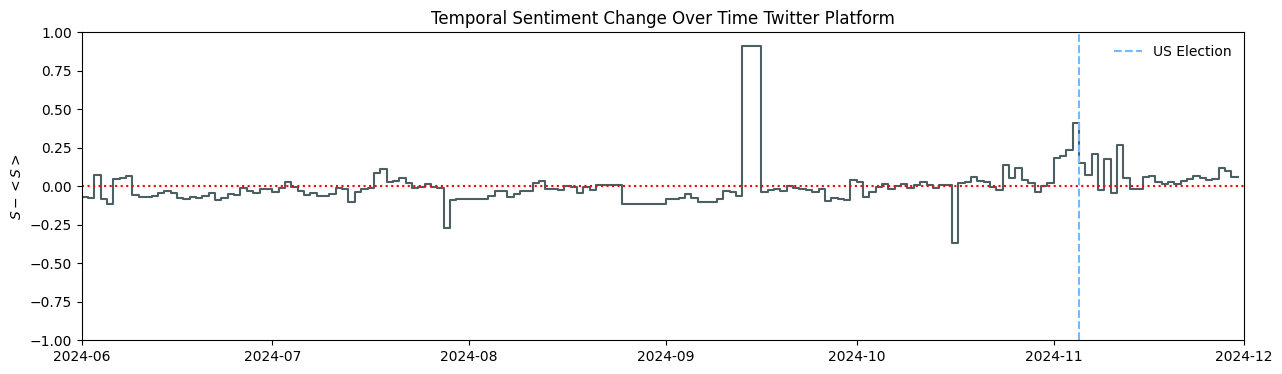

In [37]:
plt.figure(figsize=(15, 4))
plt.step(us_twitter_df['day'], us_twitter_df['sentiment_deviation'], where='pre', color="#4c5f63")
plt.axvline(pd.to_datetime(US_ELECTION_DATE), color='#74b9ff', linestyle='--', label='US Election')

plt.hlines(0, xmin=pd.to_datetime('2024-06-01'), xmax=pd.to_datetime('2024-12-01'), colors='red', linestyles='dotted')
plt.title('Temporal Sentiment Index Over Time')
plt.ylabel('$S - <S>$')
plt.legend(frameon=False)
plt.xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-12-01'))
plt.ylim(-1.0, 1.0)

plt.title('Temporal Sentiment Change Over Time Twitter Platform')

# plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
# plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.savefig('temporal_sentiment_change_twitter_us.pdf', dpi=300, bbox_inches='tight')
plt.show()

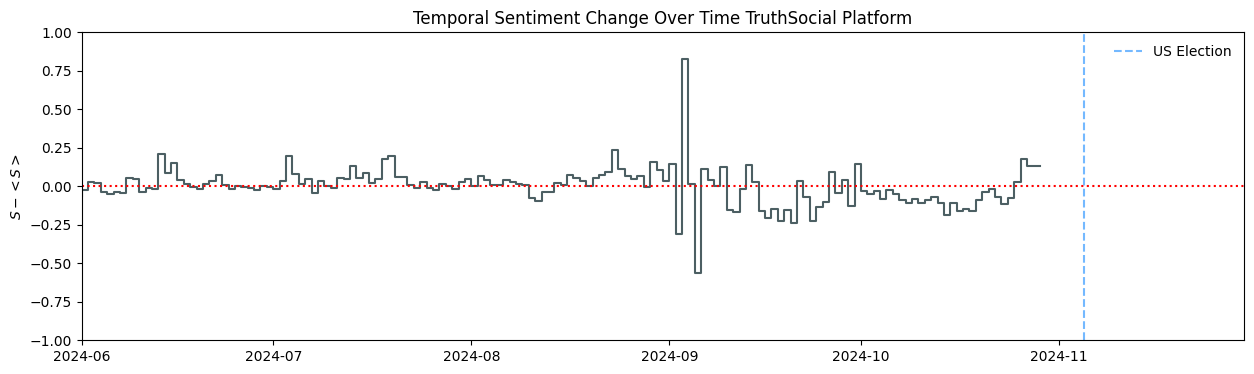

In [32]:
plt.figure(figsize=(15, 4))
plt.step(us_truthsocial_df['day'], us_truthsocial_df['sentiment_deviation'], where='pre', color="#4c5f63")
plt.axvline(pd.to_datetime(US_ELECTION_DATE), color='#74b9ff', linestyle='--', label='US Election')

plt.hlines(0, xmin=pd.to_datetime('2024-06-01'), xmax=pd.to_datetime('2024-11-30'), colors='red', linestyles='dotted')
plt.title('Temporal Sentiment Index Over Time')
plt.ylabel('$S - <S>$')
plt.legend(frameon=False)
plt.xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-11-30'))
# plt.ylim(-0.5, 0.5)
plt.ylim(-1.0, 1.0)

plt.title('Temporal Sentiment Change Over Time TruthSocial Platform')

plt.savefig('temporal_sentiment_change_truthsocial_us.pdf', dpi=300, bbox_inches='tight')
plt.show()

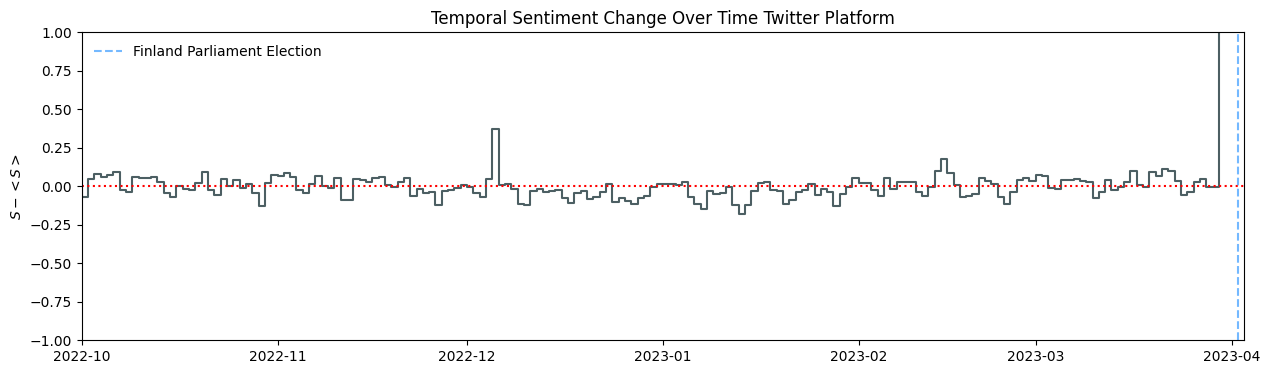

In [26]:
plt.figure(figsize=(15, 4))
plt.step(finnish_twitter_df['day'], finnish_twitter_df['sentiment_deviation'], where='pre', color="#4c5f63")
plt.axvline(pd.to_datetime(FINLAND_ELECTION_DATE), color='#74b9ff', linestyle='--', label='Finland Parliament Election')

plt.hlines(0, xmin=pd.to_datetime('2022-05-01'), xmax=pd.to_datetime('2023-04-03'), colors='red', linestyles='dotted')
plt.title('Temporal Sentiment Index Over Time')
plt.ylabel('$S - <S>$')
plt.legend(frameon=False, loc='best')
plt.xlim(pd.to_datetime('2022-10-01'), pd.to_datetime('2023-04-03'))
plt.ylim(-0.5, 0.5)
plt.ylim(-1.0, 1.0)

plt.title('Temporal Sentiment Change Over Time Twitter Platform')

plt.savefig('temporal_sentiment_change_twitter_finland.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Raw Sentiments

In [4]:
con = duckdb.connect()

con.execute("SET TimeZone = 'UTC';")

start_date = '2022-10-01'
end_date = "2023-04-02"

finnish_twitter_df_raw_sentiment = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_pos
        FROM read_json_auto('{finnish_twitter_sents_path}')
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            date_trunc('day', ts) as day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    )
    SELECT 
        day, 
        SUM(record_sentiment) as raw_sentiment_sum,
        AVG(record_sentiment) as daily_sentiment_avg,
        COUNT(*) as volume
    FROM scored_data
    GROUP BY day
    ORDER BY day
""").df()

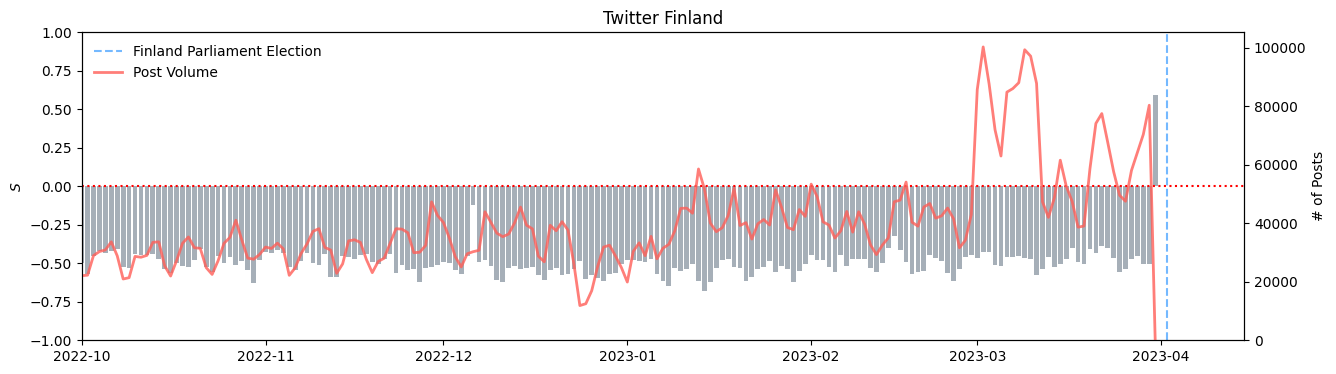

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 4))

 
ax1.plot(finnish_twitter_df_raw_sentiment['day'], 
        finnish_twitter_df_raw_sentiment['daily_sentiment_avg'], 
        color="#808e9b", 
        # label='Daily Sentiment',
        alpha=0.7)  
 
ax1.hlines(0, xmin=pd.to_datetime('2022-05-01'), xmax=pd.to_datetime('2023-04-15'), 
           colors='red', linestyles='dotted')

 
ax1.axvline(pd.to_datetime(FINLAND_ELECTION_DATE), color='#74b9ff', 
            linestyle='--', label='Finland Parliament Election')

 
ax1.set_xlim(pd.to_datetime('2022-10-01'), pd.to_datetime('2023-04-15'))
ax1.set_ylim(-1.0, 1.0) # Using your final ylim preference
ax1.set_ylabel('$S$')

ax2 = ax1.twinx()
 
ax2.bar(finnish_twitter_df_raw_sentiment['day'], 
         finnish_twitter_df_raw_sentiment['volume'], 
         color="#ff5e57", 
         linewidth=2, 
         alpha=0.8, 
         label='Post Volume')

 
ax2.set_ylabel('# of Posts')
ax2.set_ylim(bottom=0)  

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc='best')

plt.title('Twitter Finland')

# plt.savefig('temporal_sentiment_change_twitter_finland.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
con = duckdb.connect()

con.execute("SET TimeZone = 'UTC';")

start_date = '2023-01-01'
end_date = '2023-07-01'

turkey_twitter_df_raw_sentiment = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_neu,
            CAST(body->'scores'->>'LABEL_2' AS FLOAT) as p_pos
        FROM read_json_auto([
            '{turkey_twitter_sents_path_1}', 
            '{turkey_twitter_sents_path_2}'
        ])
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            date_trunc('day', ts) as day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    )
    SELECT 
        day, 
        SUM(record_sentiment) as raw_sentiment_sum,
        AVG(record_sentiment) as daily_sentiment_avg,
        COUNT(*) as volume
    FROM scored_data
    GROUP BY day
    ORDER BY day
""").df()

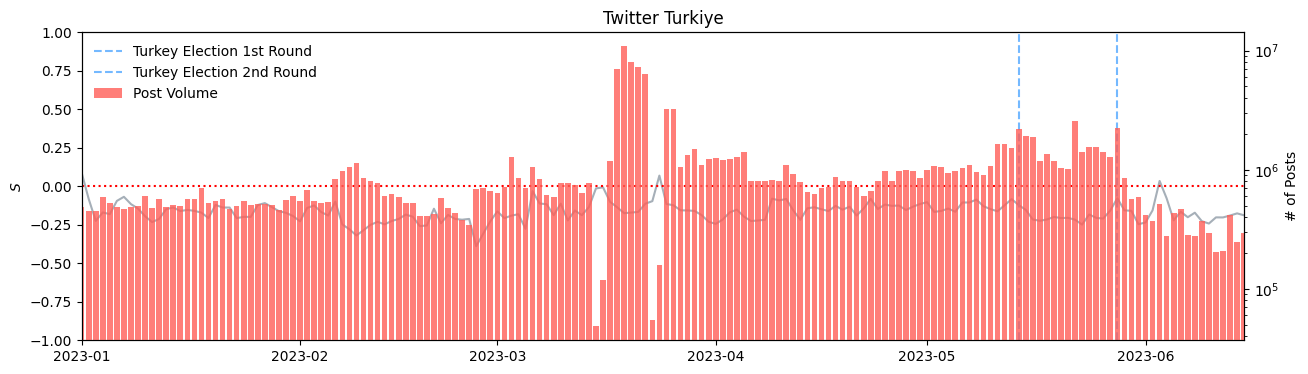

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 4))

 
ax1.plot(turkey_twitter_df_raw_sentiment['day'], 
        turkey_twitter_df_raw_sentiment['daily_sentiment_avg'], 
        color="#ff5e57", 

        # label='Daily Sentiment',
        alpha=0.7)  
 
ax1.hlines(0, xmin=pd.to_datetime('2023-01-01'), xmax=pd.to_datetime('2023-07-03'), 
           colors='red', linestyles='dotted')

 
ax1.axvline(pd.to_datetime(TURKEY_ELECTION_DATE_FIRST_ROUOND), color='#74b9ff', 
            linestyle='--', label='Turkey Election 1st Round')

ax1.axvline(pd.to_datetime(TURKEY_ELECTION_DATE_SECOND_ROUOND), color='#74b9ff', 
            linestyle='--', label='Turkey Election 2nd Round')
 
ax1.set_xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-06-15'))
ax1.set_ylim(-1.0, 1.0) # Using your final ylim preference
ax1.set_ylabel('$S$')

ax2 = ax1.twinx()
 
ax2.bar(turkey_twitter_df_raw_sentiment['day'], 
         turkey_twitter_df_raw_sentiment['volume'], 
         color="#808e9b", 
         linewidth=2, 
         alpha=0.8, 
         label='Post Volume')

ax2.set_yscale('log')
 
ax2.set_ylabel('# of Posts')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc='upper left')

plt.title('Twitter Turkiye')

# plt.savefig('temporal_sentiment_change_twitter_turkey.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
con = duckdb.connect()

con.execute("SET TimeZone = 'UTC';")

start_date = '2024-06-01'
end_date = '2024-12-01'

us_twitter_df_raw_sentiment = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_pos
        FROM read_json_auto('{usc_twitter_sents_path}')
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            date_trunc('day', ts) as day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    )
    SELECT 
        day, 
        SUM(record_sentiment) as raw_sentiment_sum,
        AVG(record_sentiment) as daily_sentiment_avg,
        COUNT(*) as volume
    FROM scored_data
    GROUP BY day
    ORDER BY day
""").df()

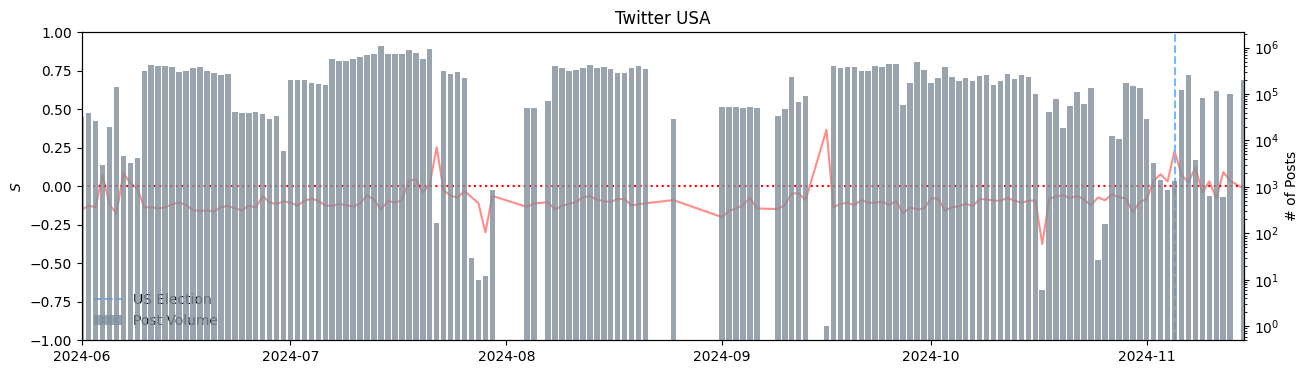

In [9]:
import numpy as np

fig, ax1 = plt.subplots(figsize=(15, 4))

 
ax1.plot(us_twitter_df_raw_sentiment['day'], 
        us_twitter_df_raw_sentiment['daily_sentiment_avg'], 
        color="#ff5e57", 
        # label='Daily Sentiment',
        alpha=0.7)  
 
ax1.hlines(0, xmin=pd.to_datetime('2024-06-01'), xmax=pd.to_datetime('2024-11-15'), 
           colors='red', linestyles='dotted')

 
ax1.axvline(pd.to_datetime(US_ELECTION_DATE), color='#74b9ff', 
            linestyle='--', label='US Election')
 
 
ax1.set_xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-11-15'))
ax1.set_ylim(-1.0, 1.0) # Using your final ylim preference
ax1.set_ylabel('$S$')

ax2 = ax1.twinx()
 
ax2.bar(us_twitter_df_raw_sentiment['day'], 
         us_twitter_df_raw_sentiment['volume'], 
         color="#808e9b", 
         linewidth=2, 
         alpha=0.8, 
         label='Post Volume')

ax2.set_yscale('log')
 
ax2.set_ylabel('# of Posts')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc='lower left')

plt.title('Twitter USA')

# plt.savefig('temporal_sentiment_change_twitter_us.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
con = duckdb.connect()

con.execute("SET TimeZone = 'UTC';")

start_date = '2024-06-01'
end_date = '2024-12-01'

us_truthsocial_df_raw_sentiment = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_pos
        FROM read_json_auto('{usc_truthsocial_sents_path}')
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            date_trunc('day', ts) as day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    )
    SELECT 
        day, 
        SUM(record_sentiment) as raw_sentiment_sum,
        AVG(record_sentiment) as daily_sentiment_avg,
        COUNT(*) as volume
    FROM scored_data
    GROUP BY day
    ORDER BY day
""").df()

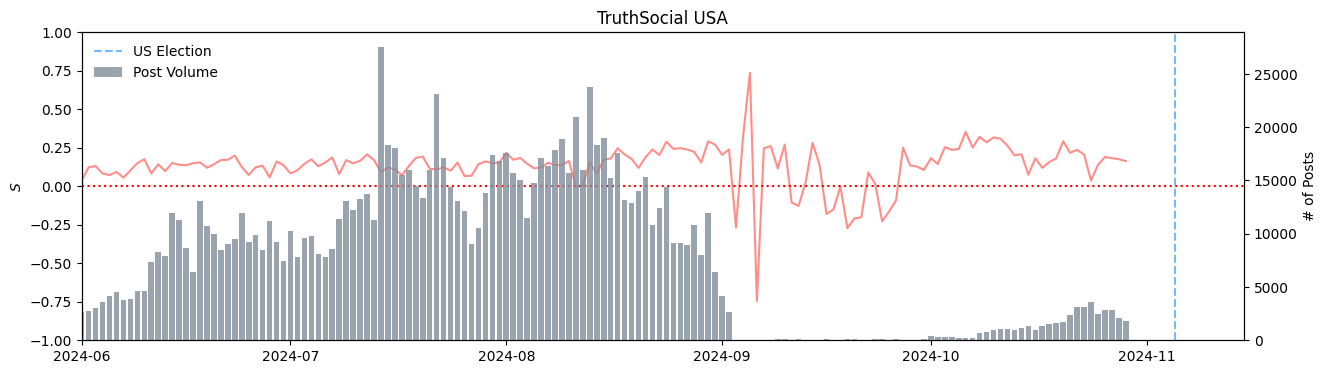

In [11]:
fig, ax1 = plt.subplots(figsize=(15, 4))

 
ax1.plot(us_truthsocial_df_raw_sentiment['day'], 
        us_truthsocial_df_raw_sentiment['daily_sentiment_avg'], 
        # label='Daily Sentiment',
        color="#ff5e57", 
        alpha=0.7)  
 
ax1.hlines(0, xmin=pd.to_datetime('2024-06-01'), xmax=pd.to_datetime('2024-11-15'), 
           colors='red', linestyles='dotted')

 
ax1.axvline(pd.to_datetime(US_ELECTION_DATE), color='#74b9ff', 
            linestyle='--', label='US Election')
 
 
ax1.set_xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-11-15'))
ax1.set_ylim(-1.0, 1.0) # Using your final ylim preference
ax1.set_ylabel('$S$')

ax2 = ax1.twinx()
 
ax2.bar(
        us_truthsocial_df_raw_sentiment['day'], 
        us_truthsocial_df_raw_sentiment['volume'], 
        color="#808e9b", 
        linewidth=2, 
        alpha=0.8, 
        label='Post Volume'
        )

# ax2.set_yscale('log')
 
ax2.set_ylabel('# of Posts')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc='best')

plt.title('TruthSocial USA')

# plt.savefig('temporal_sentiment_change_truthsocial_us.pdf', dpi=300, bbox_inches='tight')
plt.show()

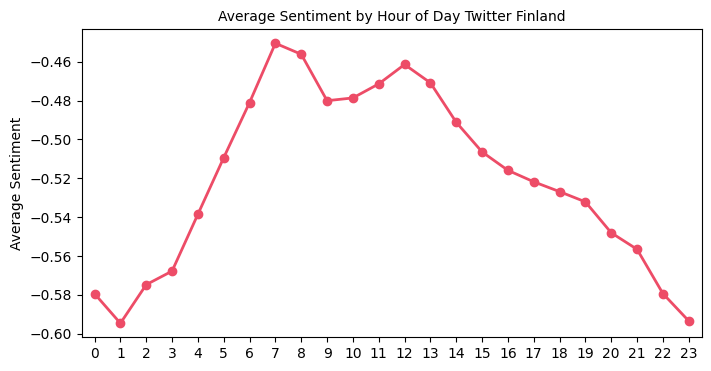

In [12]:
con = duckdb.connect()
con.execute("SET TimeZone = 'UTC';")

start_date = '2022-10-01'
end_date = "2023-04-02"

finnish_twitter_df_hourly_sentiment = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_pos
        FROM read_json_auto('{finnish_twitter_sents_path}')
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            EXTRACT(hour FROM ts) as hour_of_day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    )
    SELECT 
        hour_of_day, 
        SUM(record_sentiment) as hourly_sentiment_sum,
        AVG(record_sentiment) as hourly_sentiment_avg,
        COUNT(*) as volume
    FROM scored_data
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""").df()

 
plt.figure(figsize=(8, 4))
plt.plot(finnish_twitter_df_hourly_sentiment['hour_of_day'], 
         finnish_twitter_df_hourly_sentiment['hourly_sentiment_avg'], 
         marker='o', linestyle='-', color="#ED4C67", markersize=6, linewidth=2)

plt.title('Average Sentiment by Hour of Day Twitter Finland', fontsize=10)
plt.ylabel('Average Sentiment')
plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)
plt.show()

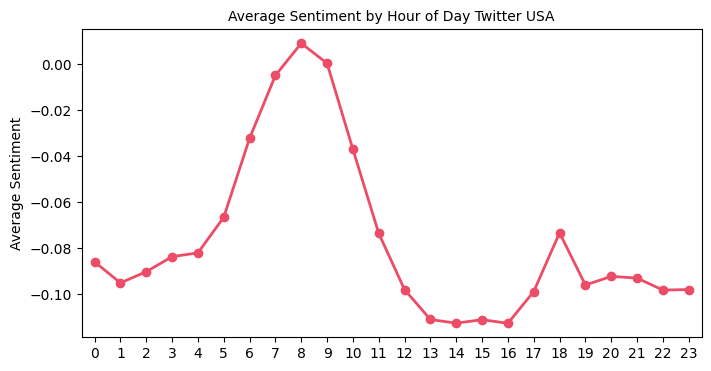

In [13]:
con = duckdb.connect()
con.execute("SET TimeZone = 'UTC';")

start_date = '2024-06-01'
end_date = '2024-12-01'


us_twitter_df_hourly_sentiment = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_pos
        FROM read_json_auto('{usc_twitter_sents_path}')
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            EXTRACT(hour FROM ts) as hour_of_day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    )
    SELECT 
        hour_of_day, 
        SUM(record_sentiment) as hourly_sentiment_sum,
        AVG(record_sentiment) as hourly_sentiment_avg,
        COUNT(*) as volume
    FROM scored_data
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""").df()

 
plt.figure(figsize=(8, 4))
plt.plot(us_twitter_df_hourly_sentiment['hour_of_day'], 
         us_twitter_df_hourly_sentiment['hourly_sentiment_avg'], 
         marker='o', linestyle='-', color="#ED4C67", markersize=6, linewidth=2)

plt.title('Average Sentiment by Hour of Day Twitter USA', fontsize=10)
plt.ylabel('Average Sentiment')
plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)
plt.show()

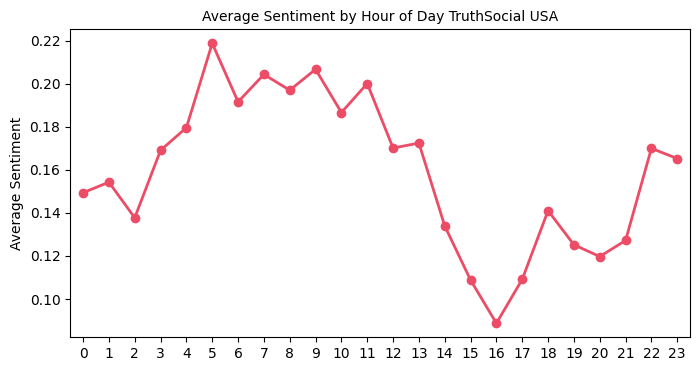

In [14]:
con = duckdb.connect()
con.execute("SET TimeZone = 'UTC';")

start_date = '2024-06-01'
end_date = '2024-12-01'


us_truthsocial_df_hourly_sentiment = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_pos
        FROM read_json_auto('{usc_truthsocial_sents_path}')
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            EXTRACT(hour FROM ts) as hour_of_day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    )
    SELECT 
        hour_of_day, 
        SUM(record_sentiment) as hourly_sentiment_sum,
        AVG(record_sentiment) as hourly_sentiment_avg,
        COUNT(*) as volume
    FROM scored_data
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""").df()

 
plt.figure(figsize=(8, 4))
plt.plot(us_truthsocial_df_hourly_sentiment['hour_of_day'], 
         us_truthsocial_df_hourly_sentiment['hourly_sentiment_avg'], 
         marker='o', linestyle='-', color="#ED4C67", markersize=6, linewidth=2)

plt.title('Average Sentiment by Hour of Day TruthSocial USA', fontsize=10)
plt.ylabel('Average Sentiment')
plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)
plt.show()

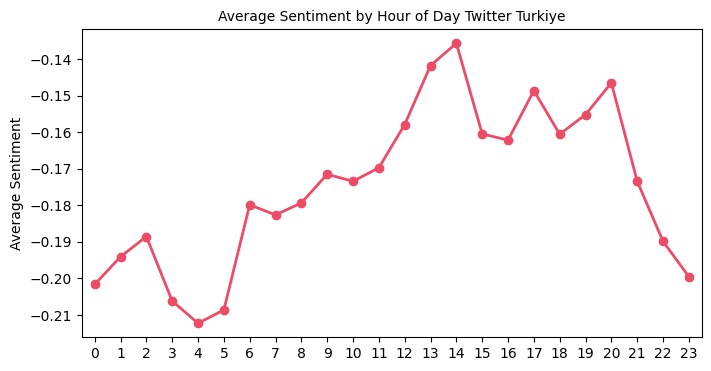

In [15]:
con = duckdb.connect()
con.execute("SET TimeZone = 'UTC';")

start_date = '2023-01-01'
end_date = '2023-07-01'

turkey_twitter_df_hourly_sentiment = con.sql(f"""
    WITH raw_data AS (
        SELECT 
            CAST(created_at AS TIMESTAMPTZ) as ts,
            CAST(body->'scores'->>'LABEL_0' AS FLOAT) as p_neg,
            CAST(body->'scores'->>'LABEL_1' AS FLOAT) as p_neu,                                             
            CAST(body->'scores'->>'LABEL_2' AS FLOAT) as p_pos
        FROM read_json_auto([
            '{turkey_twitter_sents_path_1}', 
            '{turkey_twitter_sents_path_2}'
        ])
        WHERE CAST(created_at AS TIMESTAMPTZ) BETWEEN '{start_date}' AND '{end_date}'
    ),
    scored_data AS (
        SELECT 
            EXTRACT(hour FROM ts) as hour_of_day,
            CASE 
                WHEN p_neg >= p_pos THEN -p_neg
                WHEN p_pos > p_neg THEN p_pos
                ELSE 0 
            END as record_sentiment
        FROM raw_data
    )
    SELECT 
        hour_of_day, 
        SUM(record_sentiment) as hourly_sentiment_sum,
        AVG(record_sentiment) as hourly_sentiment_avg,
        COUNT(*) as volume
    FROM scored_data
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""").df()

 
plt.figure(figsize=(8, 4))
plt.plot(turkey_twitter_df_hourly_sentiment['hour_of_day'], 
         turkey_twitter_df_hourly_sentiment['hourly_sentiment_avg'], 
         marker='o', linestyle='-', color="#ED4C67", markersize=6, linewidth=2)

plt.title('Average Sentiment by Hour of Day Twitter Turkiye', fontsize=10)
plt.ylabel('Average Sentiment')
plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)
plt.show()

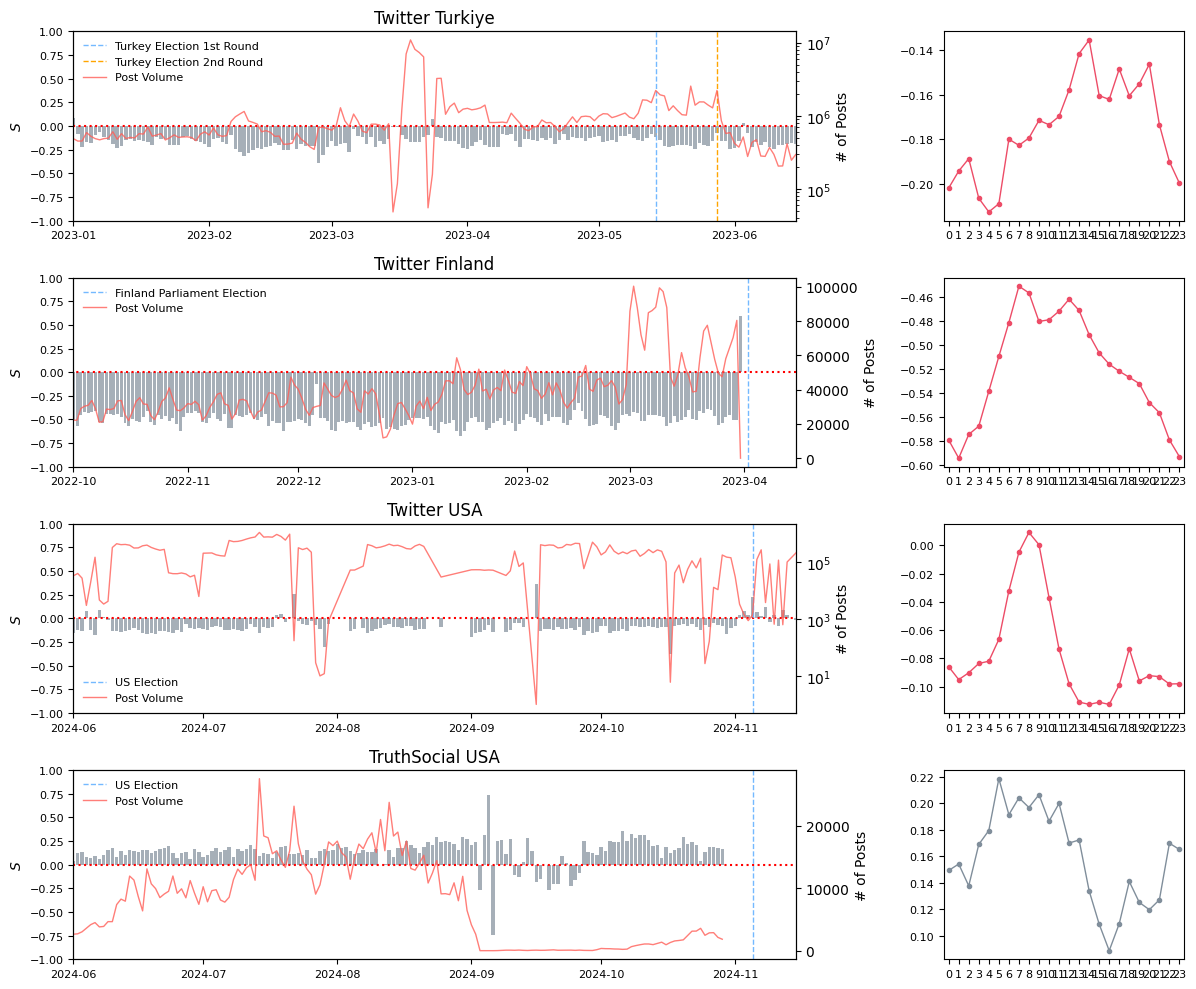

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict


COLORS = {
        "sentiment": "#808e9b",
        "volume": "#ff5e57",
        "election_event": "#74b9ff",
        "election_event_2": "orange",
        "zero_line": "red"
}


fig = plt.figure(figsize=(12, 10))

# 4 rows, 2 columns. 
# Width ratios: 3 to 1 (which equals 75% and 25%)
gs = gridspec.GridSpec(nrows=4, ncols=2, width_ratios=[3, 1])

axes_row_col = defaultdict(lambda: dict()) 
for r in range(4):
    for c in range(2):
        ax = fig.add_subplot(gs[r, c])
        axes_row_col[r][c] = ax

################# Turkiye Twitter ##################
axes_row_col[0][0].bar(turkey_twitter_df_raw_sentiment['day'], 
        turkey_twitter_df_raw_sentiment['daily_sentiment_avg'], 
        color=COLORS["sentiment"], 
        # label='Daily Sentiment',
        alpha=0.7)
 
axes_row_col[0][0].hlines(0, xmin=pd.to_datetime('2023-01-01'), xmax=pd.to_datetime('2023-07-03'), 
           colors=COLORS["zero_line"], linestyles='dotted')

 
axes_row_col[0][0].axvline(pd.to_datetime(TURKEY_ELECTION_DATE_FIRST_ROUOND), color=COLORS["election_event"], 
            linestyle='--', label='Turkey Election 1st Round', linewidth=1)

axes_row_col[0][0].axvline(pd.to_datetime(TURKEY_ELECTION_DATE_SECOND_ROUOND), color=COLORS["election_event_2"], 
            linestyle='--', label='Turkey Election 2nd Round', linewidth=1)
 
axes_row_col[0][0].set_xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-06-15'))
axes_row_col[0][0].set_ylim(-1.0, 1.0) 
axes_row_col[0][0].set_ylabel('$S$')

ax2 = axes_row_col[0][0].twinx()
 
ax2.plot(turkey_twitter_df_raw_sentiment['day'], 
         turkey_twitter_df_raw_sentiment['volume'], 
         color=COLORS["volume"], 
         linewidth=1, 
         alpha=0.8, 
         label='Post Volume')

ax2.set_yscale('log')
 
ax2.set_ylabel('# of Posts')

handles1, labels1 = axes_row_col[0][0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
axes_row_col[0][0].legend(handles1 + handles2, labels1 + labels2, frameon=False, loc='upper left', fontsize=8)
axes_row_col[0][0].set_title('Twitter Turkiye')

#######
axes_row_col[0][1].plot(turkey_twitter_df_hourly_sentiment['hour_of_day'], 
         turkey_twitter_df_hourly_sentiment['hourly_sentiment_avg'], 
         marker='o', linestyle='-', color="#ED4C67", markersize=3, linewidth=1)

 
axes_row_col[0][1].set_xticks(range(0, 24))
axes_row_col[0][1].set_xlim(-0.5, 23.5)

################# Finland Twitter ##################
 
axes_row_col[1][0].bar(finnish_twitter_df_raw_sentiment['day'], 
        finnish_twitter_df_raw_sentiment['daily_sentiment_avg'],
        color=COLORS["sentiment"],
        alpha=0.7)
axes_row_col[1][0].hlines(0, xmin=pd.to_datetime('2022-05-01'), xmax=pd.to_datetime('2023-04-15'),
           colors=COLORS["zero_line"], linestyles='dotted')
axes_row_col[1][0].axvline(pd.to_datetime(FINLAND_ELECTION_DATE), color=COLORS["election_event"],
            linestyle='--', label='Finland Parliament Election', linewidth=1)
axes_row_col[1][0].set_xlim(pd.to_datetime('2022-10-01'), pd.to_datetime('2023-04-15'))
axes_row_col[1][0].set_ylim(-1.0, 1.0)
axes_row_col[1][0].set_ylabel('$S$')
ax2 = axes_row_col[1][0].twinx()
ax2.plot(finnish_twitter_df_raw_sentiment['day'],
         finnish_twitter_df_raw_sentiment['volume'],
         color=COLORS["volume"],
         linewidth=1,
         alpha=0.8,
         label='Post Volume')
ax2.set_ylabel('# of Posts')
handles1, labels1 = axes_row_col[1][0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
axes_row_col[1][0].legend(handles1 + handles2, labels1 + labels2, frameon=False, loc='best', fontsize=8)
axes_row_col[1][0].set_title('Twitter Finland')

#######
axes_row_col[1][1].plot(finnish_twitter_df_hourly_sentiment['hour_of_day'], 
         finnish_twitter_df_hourly_sentiment['hourly_sentiment_avg'], 
         marker='o', linestyle='-', color="#ED4C67", markersize=3, linewidth=1)

axes_row_col[1][1].set_xticks(range(0, 24))
axes_row_col[1][1].set_xlim(-0.5, 23.5)

############# USA Twitter ######################
 
axes_row_col[2][0].bar(us_twitter_df_raw_sentiment['day'], 
        us_twitter_df_raw_sentiment['daily_sentiment_avg'], 
        color=COLORS["sentiment"], 
        alpha=0.7)
axes_row_col[2][0].hlines(0, xmin=pd.to_datetime('2024-06-01'), xmax=pd.to_datetime('2024-11-15'),
           colors=COLORS["zero_line"], linestyles='dotted')
axes_row_col[2][0].axvline(pd.to_datetime(US_ELECTION_DATE), color=COLORS["election_event"],
            linestyle='--', label='US Election', linewidth=1)
axes_row_col[2][0].set_xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-11-15'))
axes_row_col[2][0].set_ylim(-1.0, 1.0)
axes_row_col[2][0].set_ylabel('$S$')
ax2 = axes_row_col[2][0].twinx()
ax2.plot(us_twitter_df_raw_sentiment['day'],
         us_twitter_df_raw_sentiment['volume'],
         color=COLORS["volume"],
         linewidth=1, 
        alpha=0.8,
            label='Post Volume')
ax2.set_yscale('log')
ax2.set_ylabel('# of Posts')
handles1, labels1 = axes_row_col[2][0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
axes_row_col[2][0].legend(handles1 + handles2, labels1 + labels2, frameon=False, loc='lower left', fontsize=8)
axes_row_col[2][0].set_title('Twitter USA') 

#######
axes_row_col[2][1].plot(us_twitter_df_hourly_sentiment['hour_of_day'], 
         us_twitter_df_hourly_sentiment['hourly_sentiment_avg'], 
         marker='o', linestyle='-', color="#ED4C67", markersize=3, linewidth=1)

axes_row_col[2][1].set_xticks(range(0, 24))
axes_row_col[2][1].set_xlim(-0.5, 23.5)

################ USA TruthSocial ###################
 
axes_row_col[3][0].bar(us_truthsocial_df_raw_sentiment['day'], 
        us_truthsocial_df_raw_sentiment['daily_sentiment_avg'], 
        color=COLORS["sentiment"], 
        alpha=0.7)
axes_row_col[3][0].hlines(0, xmin=pd.to_datetime('2024-06-01'), xmax=pd.to_datetime('2024-11-15'),
           colors=COLORS["zero_line"], linestyles='dotted')
axes_row_col[3][0].axvline(pd.to_datetime(US_ELECTION_DATE), color=COLORS["election_event"],
            linestyle='--', label='US Election', linewidth=1)
axes_row_col[3][0].set_xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-11-15'))
axes_row_col[3][0].set_ylim(-1.0, 1.0)
axes_row_col[3][0].set_ylabel('$S$')
ax2 = axes_row_col[3][0].twinx()
ax2.plot(us_truthsocial_df_raw_sentiment['day'],
         us_truthsocial_df_raw_sentiment['volume'],
         color=COLORS["volume"],
         linewidth=1,
         alpha=0.8,
         label='Post Volume')
ax2.set_ylabel('# of Posts')
handles1, labels1 = axes_row_col[3][0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
axes_row_col[3][0].legend(handles1 + handles2, labels1 + labels2, frameon=False, loc='best', fontsize=8)
axes_row_col[3][0].set_title('TruthSocial USA') 

#######
axes_row_col[3][1].plot(us_truthsocial_df_hourly_sentiment['hour_of_day'], 
         us_truthsocial_df_hourly_sentiment['hourly_sentiment_avg'], 
         marker='o', linestyle='-', color=COLORS["sentiment"], markersize=3, linewidth=1)

axes_row_col[3][1].set_xticks(range(0, 24))
axes_row_col[3][1].set_xlim(-0.5, 23.5)
 

###############################################
for i in range(4):
    axes_row_col[i][1].tick_params(axis='both', which='major', labelsize=8)
    axes_row_col[i][0].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.show()

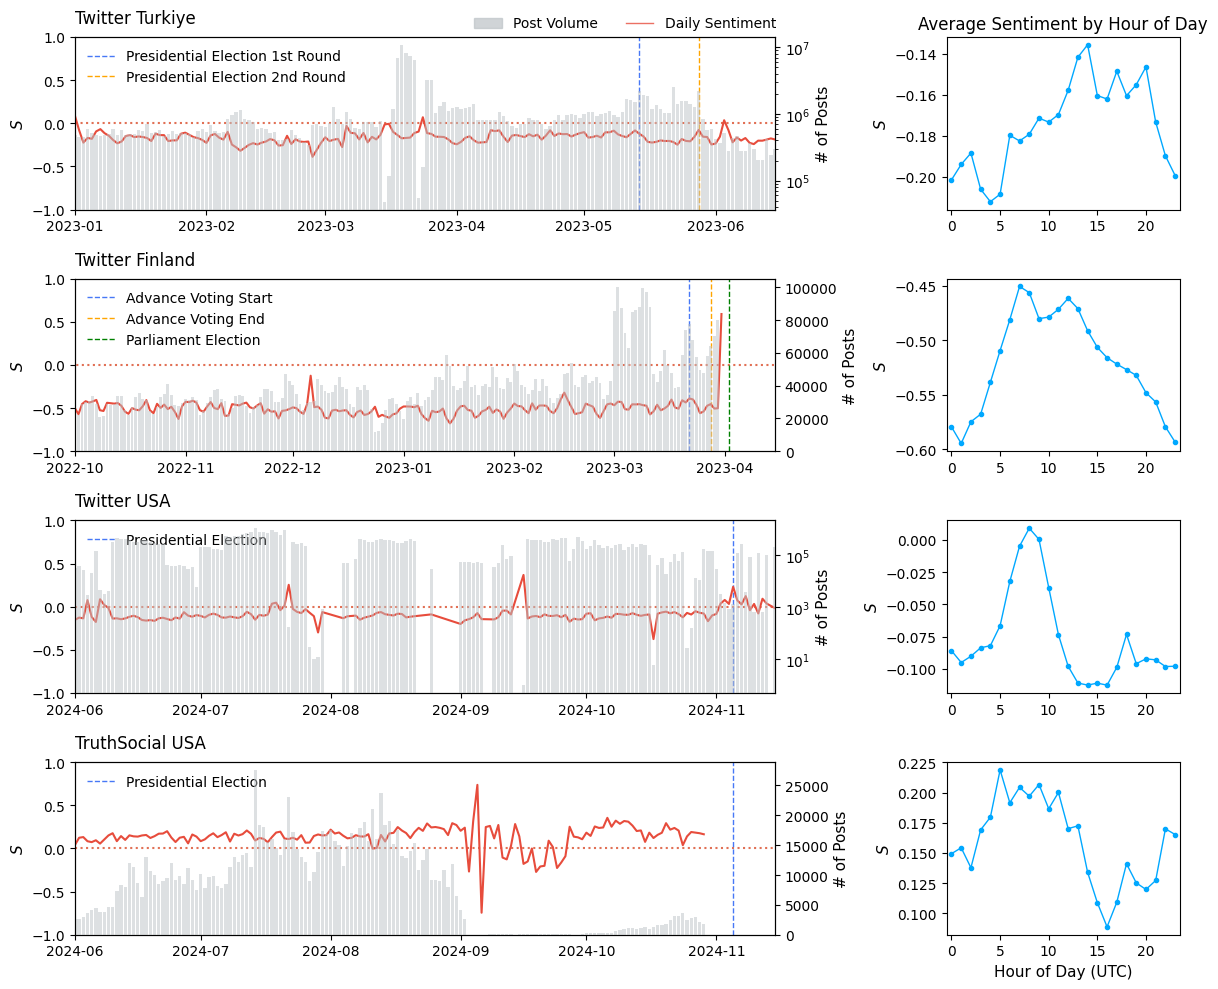

In [40]:
# Finland Advanced Voting: March 22 to March 28 2023
FINLAND_ELECTION_DATE_ADVANCE_START = '2023-03-22'
FINLAND_ELECTION_DATE_ADVANCE_END = '2023-03-28'

FONTSIZES = {
    "title": 12,
    "axis_labels": 11,
    "ticks": 10,
    "legend": 10
}

COLORS = {
    "volume": "#bdc3c7",
    "sentiment": "#e74c3c",
    "election_event": "#4778f6",
    "election_event_2": "orange",
    "election_event_3": "green",
    "zero_line": "#e17055",
    "hourly_line": "#00a8ff"
}

plot_configs = [
    {
        "title": "Twitter Turkiye",
    "raw_df": turkey_twitter_df_raw_sentiment,
        "hourly_df": turkey_twitter_df_hourly_sentiment,
        "date_lims": ('2023-01-01', '2023-06-15'),
        "hline_lims": ('2023-01-01', '2023-07-03'), 
        "elections": [
            (TURKEY_ELECTION_DATE_FIRST_ROUOND, COLORS["election_event"], 'Presidential Election 1st Round'),
            (TURKEY_ELECTION_DATE_SECOND_ROUOND, COLORS["election_event_2"], 'Presidential Election 2nd Round')
        ],
        "log_y": True,
        "legend_loc": "upper left",
        "hourly_color": COLORS["hourly_line"]
    },
    {
        "title": "Twitter Finland",
        "raw_df": finnish_twitter_df_raw_sentiment,
        "hourly_df": finnish_twitter_df_hourly_sentiment,
        "date_lims": ('2022-10-01', '2023-04-15'),
        "hline_lims": ('2022-05-01', '2023-04-15'),
        "elections": [
            (FINLAND_ELECTION_DATE_ADVANCE_START, COLORS["election_event"], 'Advance Voting Start'),
            (FINLAND_ELECTION_DATE_ADVANCE_END, COLORS["election_event_2"], 'Advance Voting End'),
            (FINLAND_ELECTION_DATE, COLORS["election_event_3"], 'Parliament Election')
        ],
        "log_y": False,
        "legend_loc": "best",
        "hourly_color": COLORS["hourly_line"]
    },
    {
        "title": "Twitter USA",
        "raw_df": us_twitter_df_raw_sentiment,
        "hourly_df": us_twitter_df_hourly_sentiment,
        "date_lims": ('2024-06-01', '2024-11-15'),
        "hline_lims": ('2024-06-01', '2024-11-15'),
        "elections": [
            (US_ELECTION_DATE, COLORS["election_event"], 'Presidential Election')
        ],
        "log_y": True,
        "legend_loc": "best",
        "hourly_color": COLORS["hourly_line"]
    },
    {
        "title": "TruthSocial USA",
        "raw_df": us_truthsocial_df_raw_sentiment,
        "hourly_df": us_truthsocial_df_hourly_sentiment, 
        "date_lims": ('2024-06-01', '2024-11-15'),
        "hline_lims": ('2024-06-01', '2024-11-15'),
        "elections": [
            (US_ELECTION_DATE, COLORS["election_event"], 'Presidential Election')
        ],
        "log_y": False,
        "legend_loc": "best",
        "hourly_color": COLORS["hourly_line"]
    }
]

fig, axes = plt.subplots(
    nrows=4, 
    ncols=2, 
    figsize=(12, 10), 
    gridspec_kw={'width_ratios': [3, 1]}
)

for i, config in enumerate(plot_configs):
    ax_main = axes[i, 0]
    ax_hourly = axes[i, 1]
    
    # ---------- LEFT PLOT: Raw Sentiment & Volume ----------
    raw_df = config["raw_df"]
    
    ax_main.plot(raw_df['day'], raw_df['daily_sentiment_avg'], color=COLORS["sentiment"], alpha=1, zorder=10)
    ax_main.hlines(0, xmin=pd.to_datetime(config["hline_lims"][0]), xmax=pd.to_datetime(config["hline_lims"][1]), 
                   colors=COLORS["zero_line"], linestyles='dotted')
    
    for date, color, label in config["elections"]:
        ax_main.axvline(pd.to_datetime(date), color=color, linestyle='--', label=label, linewidth=1)
    
    ax_main.set_xlim(pd.to_datetime(config["date_lims"][0]), pd.to_datetime(config["date_lims"][1]))
    ax_main.set_ylim(-1.0, 1.0)
    ax_main.set_ylabel('$S$', fontsize=FONTSIZES["axis_labels"])
    ax_main.tick_params(axis='both', which='major', labelsize=FONTSIZES["ticks"])

    ax_vol = ax_main.twinx()
    ax_vol.bar(raw_df['day'], raw_df['volume'], color=COLORS["volume"], linewidth=1, alpha=0.5)
    ax_vol.set_ylabel('# of Posts', fontsize=FONTSIZES["axis_labels"])
    ax_vol.tick_params(axis='both', which='major', labelsize=FONTSIZES["ticks"])
    if config["log_y"]:
        ax_vol.set_yscale('log')
        
    handles1, labels1 = ax_main.get_legend_handles_labels()
    handles2, labels2 = ax_vol.get_legend_handles_labels()
    
    ax_main.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc=config["legend_loc"], fontsize=FONTSIZES["legend"])

    ax_main.set_title(config["title"], loc='left', fontsize=FONTSIZES["title"], pad=10)

    # ---------- RIGHT PLOT: Hourly Sentiment ----------
    hourly_df = config["hourly_df"]
    
    ax_hourly.plot(hourly_df['hour_of_day'], hourly_df['hourly_sentiment_avg'], 
                   marker='o', linestyle='-', color=config["hourly_color"], markersize=3, linewidth=1)
    
    # ax_hourly.set_xticks(range(0, 24))
    ax_hourly.set_xlim(-0.5, 23.5)
    ax_hourly.set_ylabel('$S$', fontsize=FONTSIZES["axis_labels"])
    ax_hourly.tick_params(axis='both', which='major', labelsize=FONTSIZES["ticks"])
    
    if i < 3:
        pass
    else:
        ax_hourly.set_xlabel('Hour of Day (UTC)', fontsize=FONTSIZES["axis_labels"]) 

    if i == 0:
        ax_hourly.set_title('Average Sentiment by Hour of Day', fontsize=FONTSIZES["title"])


# global legend at the top of the figure
# I only want sentiment bar color and red post count color in the legend, so I will manually create legend entries for those.
labels = ['Post Volume', 'Daily Sentiment']
handles = [
    plt.Rectangle((0,0), 0.1, 0.1, color=COLORS["volume"], alpha=0.7), 
    plt.Line2D([0], [0], color=COLORS["sentiment"], linewidth=1, alpha=0.8)
]

by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=2, frameon=False, fontsize=FONTSIZES["legend"], bbox_to_anchor=(0.525, 0.99))

plt.tight_layout()
plt.subplots_adjust(hspace=0.4) 
plt.savefig('combined_sentiment_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()